# MELHORANDO O MODELO + GRÁFICOS DE PREVISÃO DE VENDA - PARA CADA INSUMO

1. Importar Bibliotecas e Carregar Dados

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Carregar dados do Excel
df = pd.read_excel('insumos_vendidos_por_dia.xlsx')

2. Pré-processamento e Feature Engineering

In [2]:
# Converter coluna 'Data' para datetime e extrair features temporais
df['Data'] = pd.to_datetime(df['Data'])
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia'] = df['Data'].dt.day
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0=Segunda, 6=Domingo

# Adicionar variáveis relevantes
# 1. Feriados (exemplo para Brasil)
feriados = ['2024-01-01', '2024-04-21', '2024-12-25', '2025-01-01']  # Adapte com suas datas
df['Feriado'] = df['Data'].isin(pd.to_datetime(feriados)).astype(int)

# 2. Fim de semana
df['Fim_de_Semana'] = df['Dia_Semana'].isin([5, 6]).astype(int)  # 5=Sábado, 6=Domingo

# 3. Média móvel de 7 dias (para 'ARR')
df['ARR_Media_7d'] = df['ARR'].rolling(window=7).mean().shift(1)  # Usa dados passados

# Remover linhas com NaN (geradas pela média móvel)
df = df.dropna()

3. Seleção de Features e Target

In [3]:
# Selecionar colunas de insumos (excluindo datas e colunas não numéricas)
insumos = df.columns[1:18]  # Colunas de 'ARR' até 'TUTU'

# Definir features (X) e target (y) para um insumo (ex: ARR)
features = ['Ano', 'Mes', 'Dia', 'Dia_Semana', 'Feriado', 'Fim_de_Semana', 'ARR_Media_7d']
X = df[features]
y = df['ARR']  # Alvo: vendas do insumo ARR

4. Divisão dos Dados e Treinamento do Modelo

In [4]:
# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Treinar modelo (Random Forest como exemplo)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

5. Avaliação do Modelo

In [5]:
# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Importância das features
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportância das Features:")
print(importancias)

MAE: 1890.98
R²: -0.23

Importância das Features:
Dia_Semana       0.458210
Fim_de_Semana    0.144386
ARR_Media_7d     0.131190
Dia              0.128926
Mes              0.102867
Ano              0.034420
Feriado          0.000000
dtype: float64


6. Visualização dos Resultados

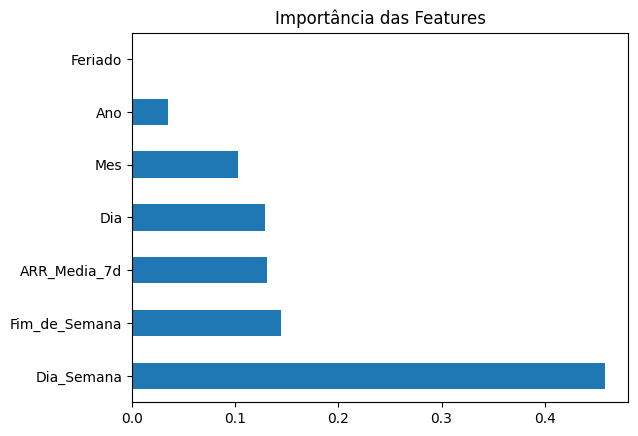

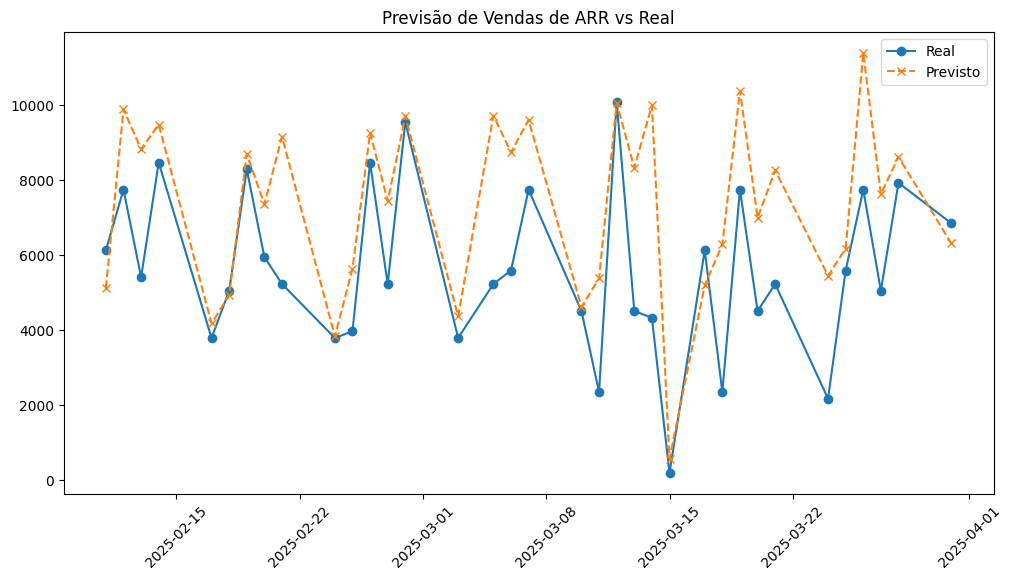

In [6]:
# Gráfico de importância das features
importancias.plot(kind='barh', title='Importância das Features')
plt.show()

# Comparação entre valores reais e previstos
plt.figure(figsize=(12, 6))
plt.plot(df['Data'][-len(y_test):], y_test, label='Real', marker='o')
plt.plot(df['Data'][-len(y_test):], y_pred, label='Previsto', linestyle='--', marker='x')
plt.title('Previsão de Vendas de ARR vs Real')
plt.legend()
plt.xticks(rotation=45)
plt.show()

7. Previsão para Futuros Dias

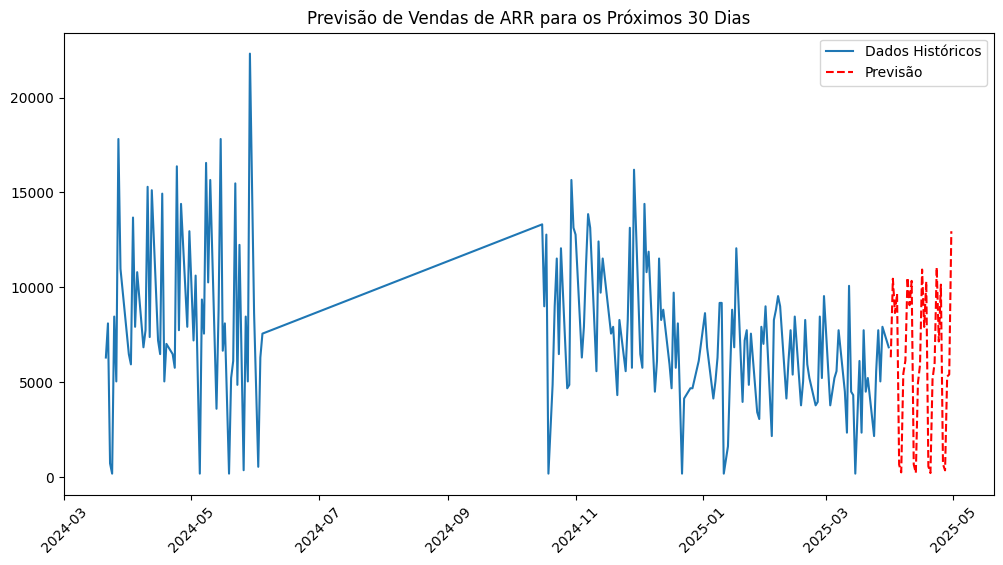

In [7]:
# Criar datas futuras (próximos 30 dias)
future_dates = pd.date_range(start=df['Data'].max() + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame({'Data': future_dates})

# Extrair features temporais para o futuro
future_df['Ano'] = future_df['Data'].dt.year
future_df['Mes'] = future_df['Data'].dt.month
future_df['Dia'] = future_df['Data'].dt.day
future_df['Dia_Semana'] = future_df['Data'].dt.dayofweek
future_df['Feriado'] = future_df['Data'].isin(pd.to_datetime(feriados)).astype(int)
future_df['Fim_de_Semana'] = future_df['Dia_Semana'].isin([5, 6]).astype(int)

# Calcular média móvel para o futuro (usando o último valor disponível)
last_7d_mean = df['ARR'].tail(7).mean()
future_df['ARR_Media_7d'] = last_7d_mean  # Simplificação (em produção, use uma lógica mais robusta)

# Prever
X_future = future_df[features]
future_df['ARR_Previsto'] = model.predict(X_future)

# Visualizar previsões
plt.figure(figsize=(12, 6))
plt.plot(df['Data'], df['ARR'], label='Dados Históricos')
plt.plot(future_df['Data'], future_df['ARR_Previsto'], label='Previsão', linestyle='--', color='red')
plt.title('Previsão de Vendas de ARR para os Próximos 30 Dias')
plt.legend()
plt.xticks(rotation=45)
plt.show()

1. Importar Bibliotecas e Carregar Dados

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Carregar dados do Excel
df = pd.read_excel('insumos_vendidos_por_dia.xlsx')

2. Pré-processamento e Feature Engineering

In [9]:
# Converter coluna 'Data' para datetime e extrair features temporais
df['Data'] = pd.to_datetime(df['Data'])
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia'] = df['Data'].dt.day
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0=Segunda, 6=Domingo

# Adicionar variáveis relevantes
feriados = ['2024-01-01', '2024-12-25', '2025-01-01']  # Adapte com suas datas
df['Feriado'] = df['Data'].isin(pd.to_datetime(feriados)).astype(int)
df['Fim_de_Semana'] = df['Dia_Semana'].isin([5, 6]).astype(int)

# Lista de insumos (colunas 2 a 18)
insumos = df.columns[1:18]  # ['ARR', 'BAC', 'BERIN', ..., 'TUTU']

3. Modelagem e Previsão para Cada Insumo

In [10]:
# Dicionário para armazenar resultados
resultados = {}

# Loop para cada insumo
for insumo in insumos:
    print(f"\n--- Modelando {insumo} ---")
    
    # Criar médias móveis (7 dias) para o insumo atual
    df[f'{insumo}_Media_7d'] = df[insumo].rolling(window=7).mean().shift(1)
    df_temp = df.dropna()  # Remover linhas com NaN
    
    # Definir features e target
    features = ['Ano', 'Mes', 'Dia', 'Dia_Semana', 'Feriado', 'Fim_de_Semana', f'{insumo}_Media_7d']
    X = df_temp[features]
    y = df_temp[insumo]
    
    # Dividir em treino (80%) e teste (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    
    # Treinar modelo (Random Forest)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Avaliar
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MAE: {mae:.2f}, R²: {r2:.2f}")
    
    # Salvar resultados
    resultados[insumo] = {
        'modelo': model,
        'features': features,
        'mae': mae,
        'r2': r2
    }


--- Modelando ARR ---
MAE: 1890.98, R²: -0.23

--- Modelando BAC ---
MAE: 126.21, R²: 0.23

--- Modelando BERIN ---
MAE: 65.48, R²: 0.77

--- Modelando CARN ---
MAE: 325.56, R²: 0.74

--- Modelando COST ---
MAE: 74.10, R²: 0.92

--- Modelando COST S ---
MAE: 83.87, R²: 0.62

--- Modelando FEIJ ---
MAE: 844.29, R²: 0.33

--- Modelando FEIJOA ---
MAE: 498.14, R²: 0.75

--- Modelando FRAL ---
MAE: 185.71, R²: 0.53

--- Modelando FRANG ---
MAE: 340.15, R²: 0.38

--- Modelando MAMI ---
MAE: 110.57, R²: 0.61

--- Modelando MASS ---
MAE: 527.71, R²: 0.01

--- Modelando MOLH ---
MAE: 249.55, R²: 0.32

--- Modelando MOLH B ---
MAE: 186.79, R²: 0.66

--- Modelando PEIX ---
MAE: 161.13, R²: -9.36

--- Modelando POL ---
MAE: 58.24, R²: -1.09

--- Modelando TUTU ---
MAE: 311.86, R²: 0.50


4. Previsão para os Próximos 30 Dias

In [11]:
# Criar datas futuras
future_dates = pd.date_range(start=df['Data'].max() + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame({'Data': future_dates})

# Extrair features temporais para o futuro
future_df['Ano'] = future_df['Data'].dt.year
future_df['Mes'] = future_df['Data'].dt.month
future_df['Dia'] = future_df['Data'].dt.day
future_df['Dia_Semana'] = future_df['Data'].dt.dayofweek
future_df['Feriado'] = future_df['Data'].isin(pd.to_datetime(feriados)).astype(int)
future_df['Fim_de_Semana'] = future_df['Dia_Semana'].isin([5, 6]).astype(int)

# Prever cada insumo
for insumo in insumos:
    features = resultados[insumo]['features']
    
    # Calcular média móvel futura (usando o último valor disponível)
    last_7d_mean = df[insumo].tail(7).mean()
    future_df[f'{insumo}_Media_7d'] = last_7d_mean
    
    # Prever
    X_future = future_df[features]
    future_df[f'{insumo}_Previsto'] = resultados[insumo]['modelo'].predict(X_future)

5. Visualização das Previsões

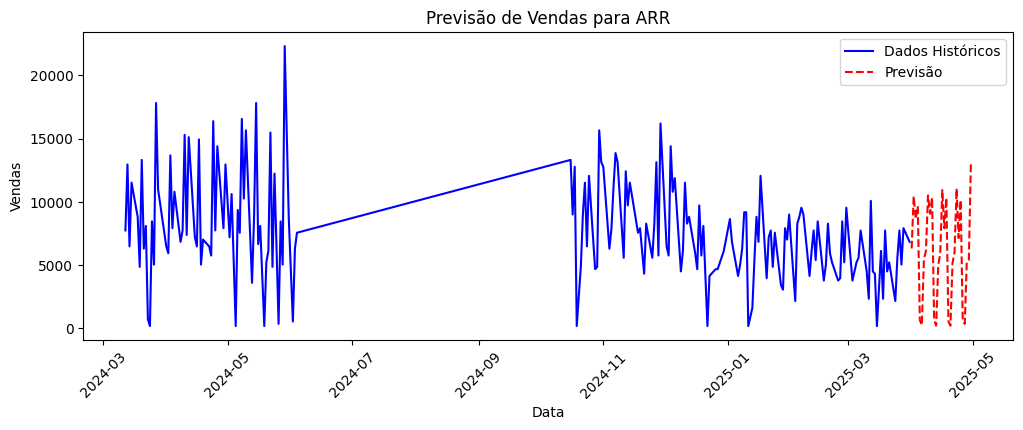

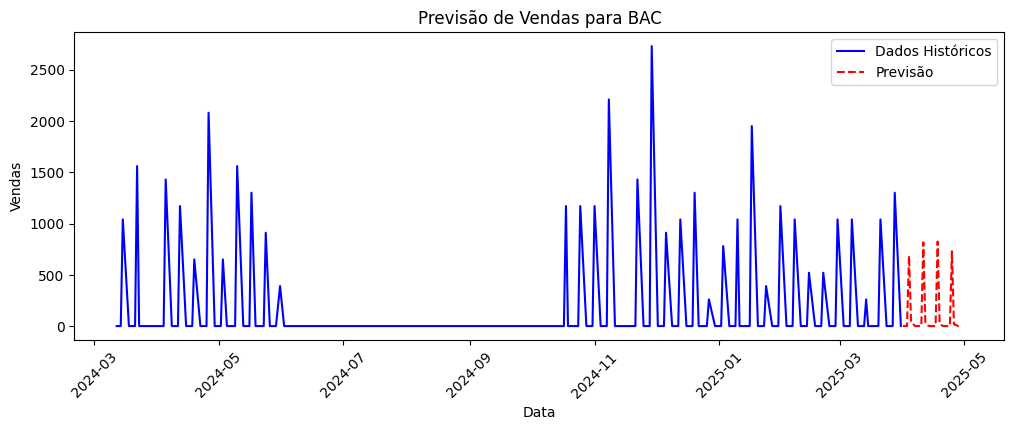

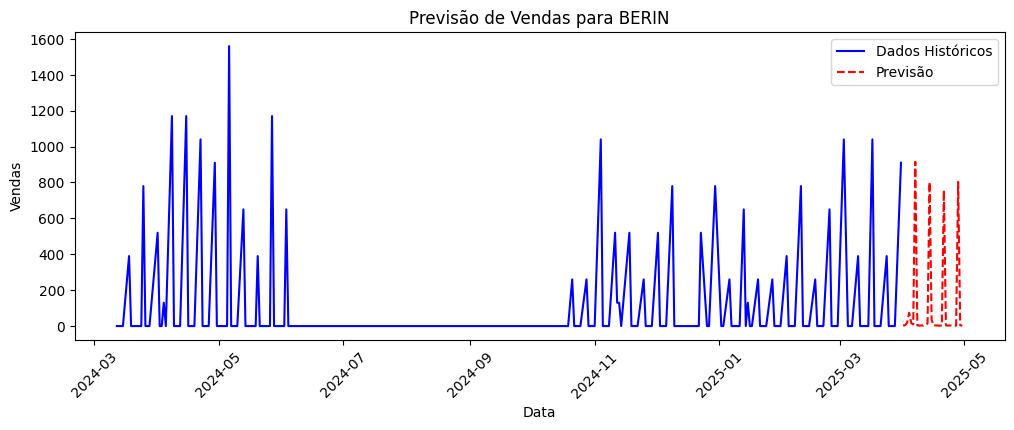

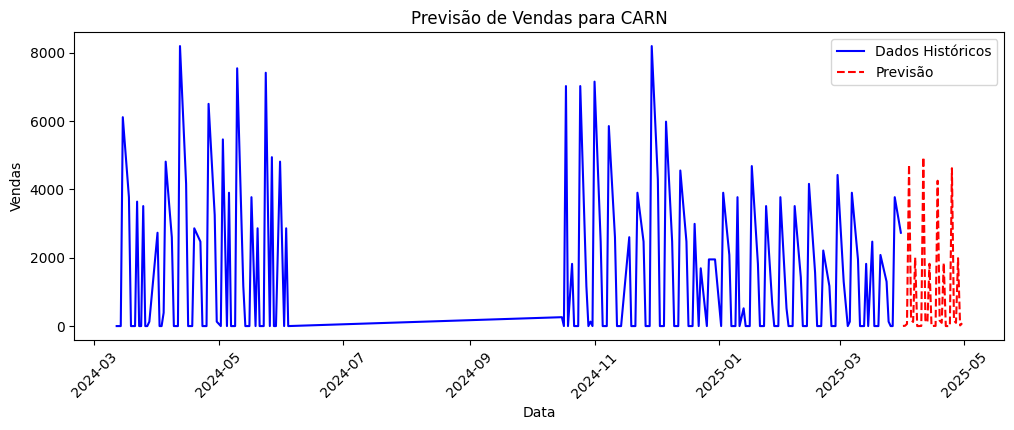

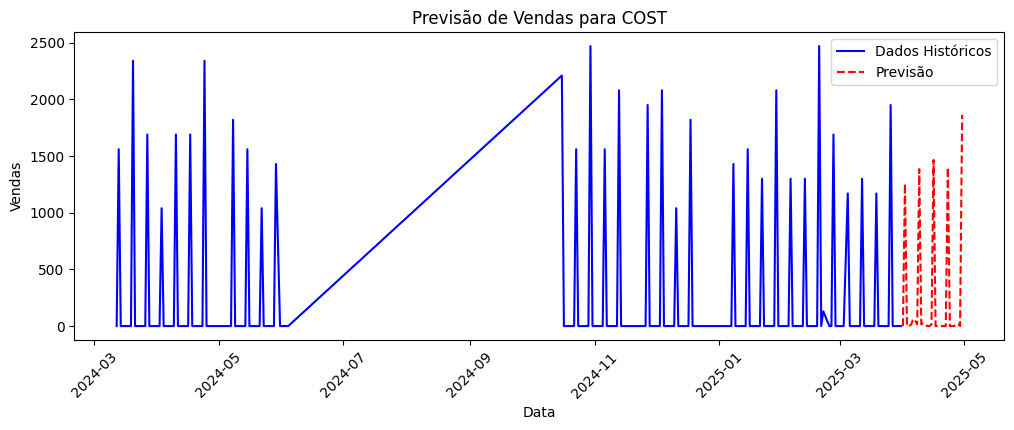

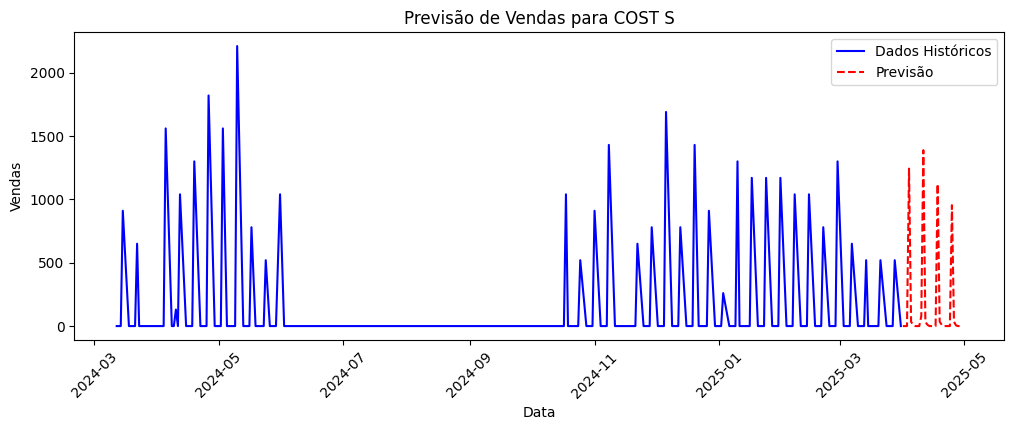

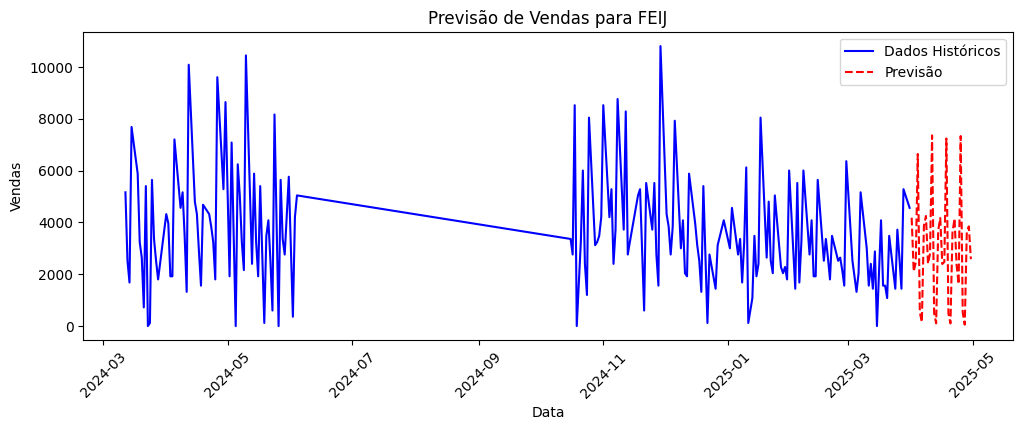

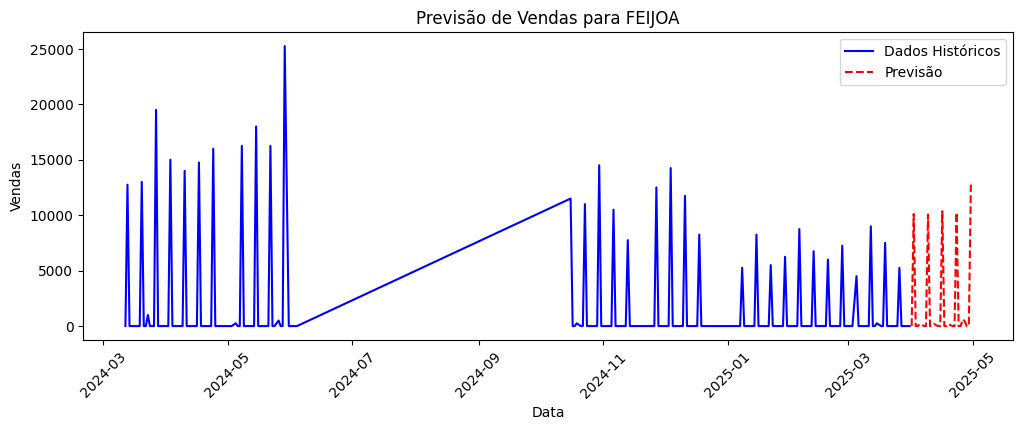

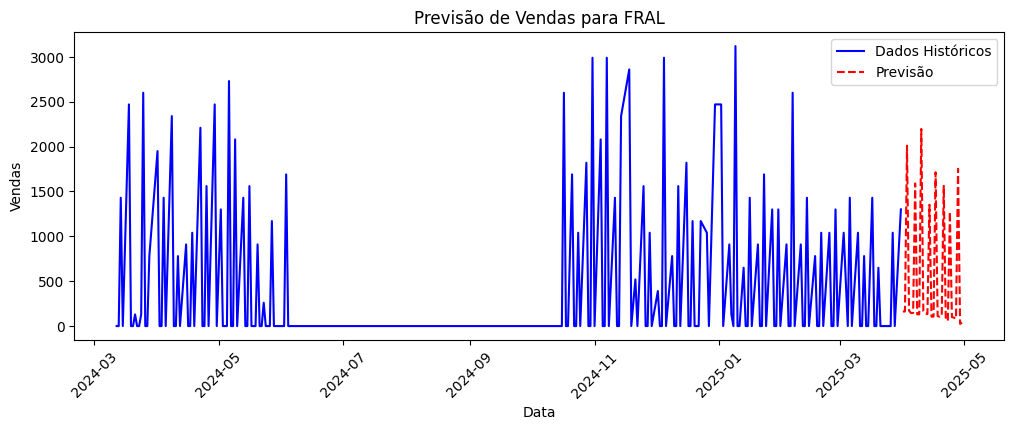

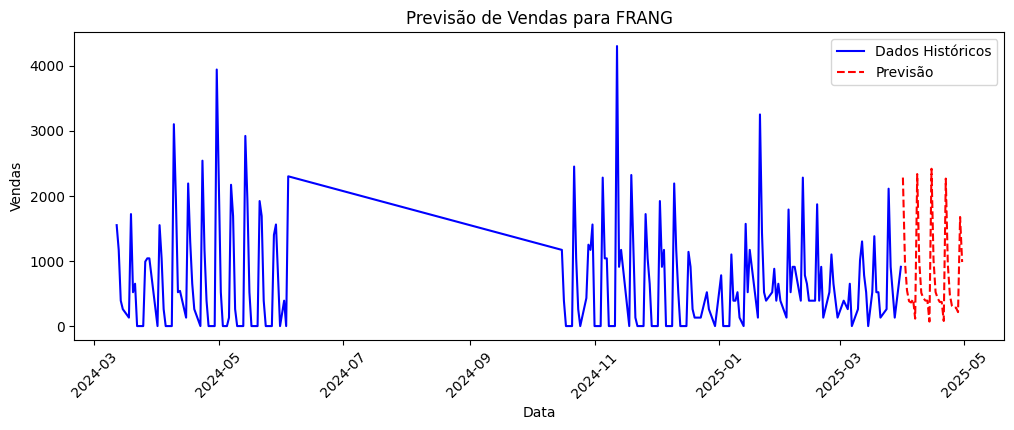

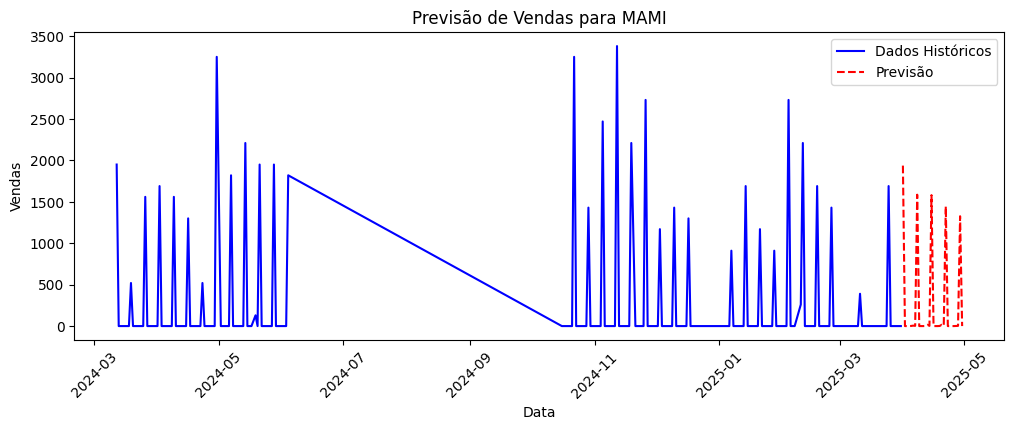

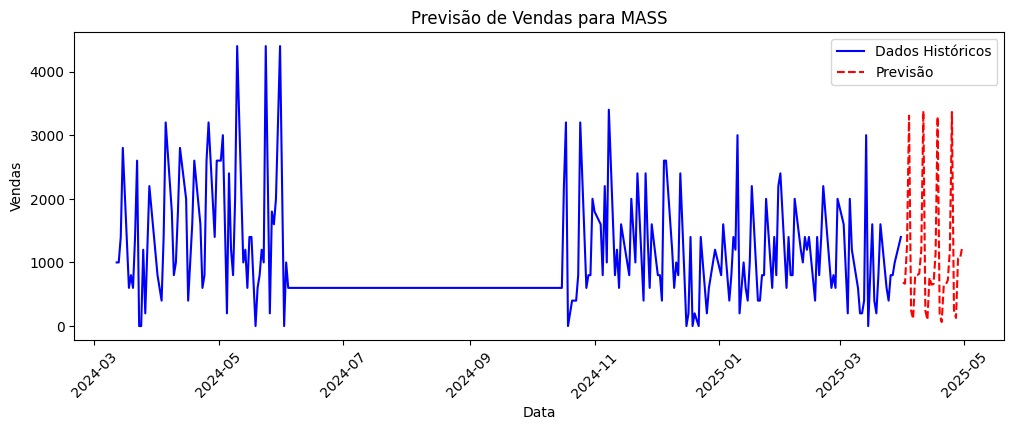

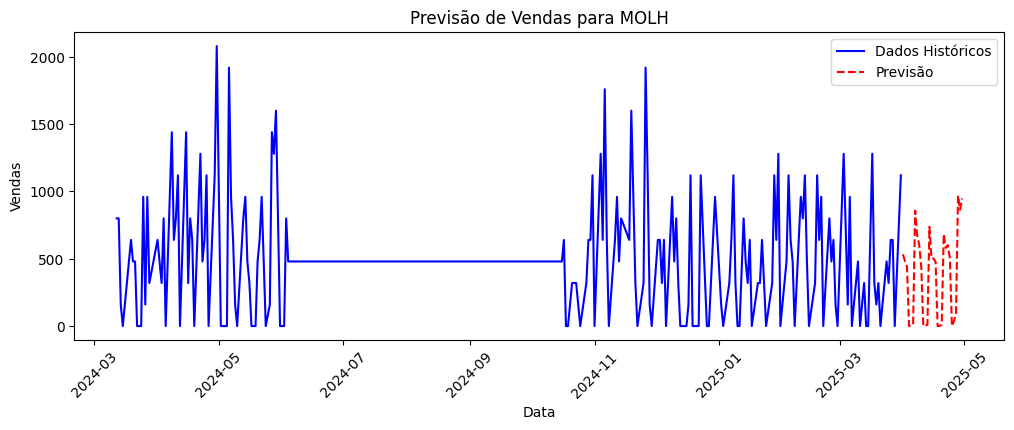

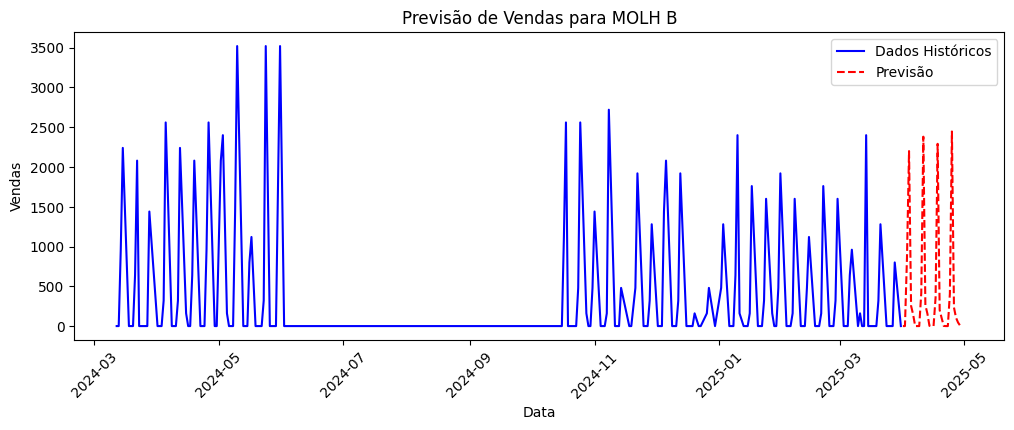

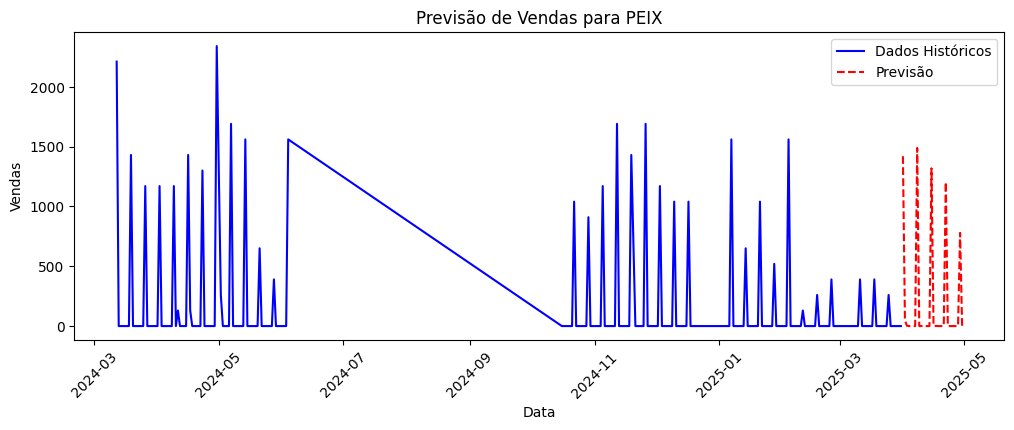

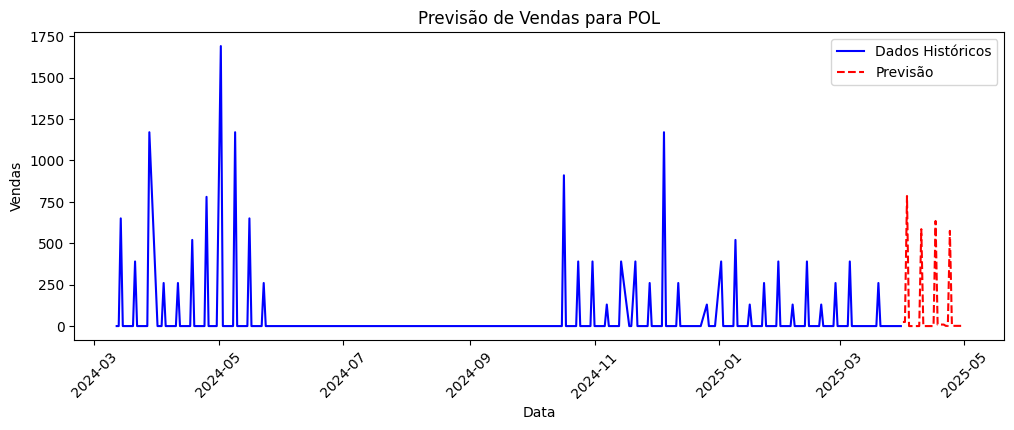

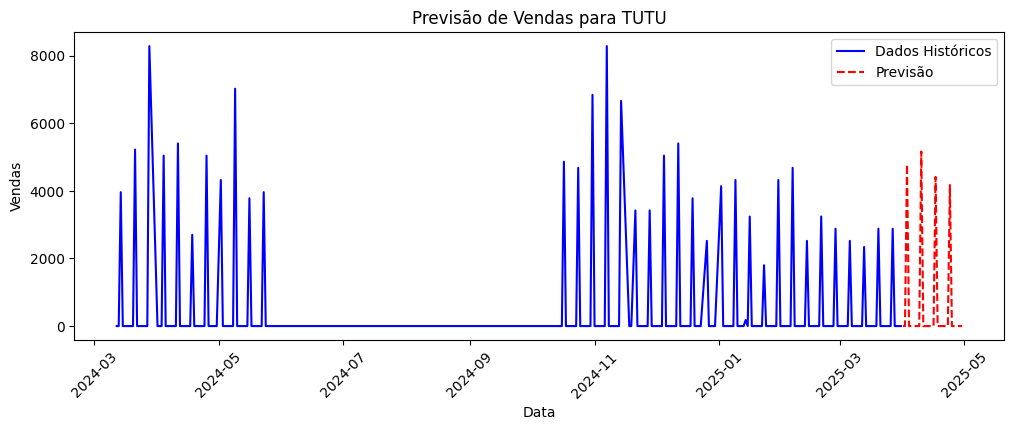

In [12]:
# Gráfico para cada insumo
for insumo in insumos:
    plt.figure(figsize=(12, 4))
    plt.plot(df['Data'], df[insumo], label='Dados Históricos', color='blue')
    plt.plot(future_df['Data'], future_df[f'{insumo}_Previsto'], label='Previsão', linestyle='--', color='red')
    plt.title(f'Previsão de Vendas para {insumo}')
    plt.xlabel('Data')
    plt.ylabel('Vendas')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()